# Q7 — Stockout Distortion Analysis
Validates `src/xai/stockout_analysis.py`.

Answers: **Could past stockouts have distorted the demand signal for this SKU?**

Since inventory data is unavailable, stockouts are proxied by zero or near-zero `sales_lag_7` values.

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.stockout_analysis import (
    flag_potential_stockouts,
    analyze_zero_lag_shap_impact,
    estimate_censored_demand,
    generate_stockout_text,
)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load Model and Data

In [2]:
model    = joblib.load(MODEL_PATH)
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')
full_df  = pd.concat([train_df, test_df], ignore_index=True)
full_df['date'] = pd.to_datetime(full_df['date'], errors='coerce')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in test_df.columns if c not in DROP_COLS]

X_test = test_df[feature_cols].copy()

# Pick a SKU that has some zero-lag periods
zero_counts = test_df.groupby('item_id')['sales_lag_7'].apply(lambda x: (x <= 0.5).sum())
target_sku  = zero_counts[zero_counts > 0].sort_values(ascending=False).index[0]
print(f'Chosen SKU: {target_sku}  (zero-lag periods in test: {zero_counts[target_sku]})')

Chosen SKU: FOODS_3_745  (zero-lag periods in test: 11)


## 3) Flag Potential Stockout Periods

In [3]:
flagged_df = flag_potential_stockouts(full_df, lag_col='sales_lag_7', zero_threshold=0.5)

sku_flagged = flagged_df[flagged_df['item_id'] == target_sku]
n_total     = len(sku_flagged)
n_stockout  = int(sku_flagged['is_potential_stockout'].sum())

print(f'SKU: {target_sku}')
print(f'Total periods : {n_total}')
print(f'Flagged stockouts: {n_stockout} ({n_stockout/n_total*100:.1f}%)')
print()
print(sku_flagged[['date', 'sales_lag_7', TARGET, 'is_potential_stockout']].head(15).to_string(index=False))

SKU: FOODS_3_745
Total periods : 59
Flagged stockouts: 25 (42.4%)

      date  sales_lag_7  aggregated_sales_7  is_potential_stockout
2015-01-07          0.0                   0                      1
2015-01-14          0.0                   0                      1
2015-01-21          0.0                   0                      1
2015-01-28          0.0                   1                      1
2015-02-04          1.0                   1                      0
2015-02-11          1.0                   1                      0
2015-02-18          1.0                   2                      0
2015-02-25          2.0                   2                      0
2015-03-04          2.0                   4                      0
2015-03-11          4.0                   2                      0
2015-03-18          2.0                   2                      0
2015-03-25          2.0                   3                      0
2015-04-01          3.0                   4                   

## 4) Analyze SHAP Distortion During Zero-Lag Periods

In [4]:
impact_df = analyze_zero_lag_shap_impact(
    model        = model,
    X            = X_test,
    item_ids     = test_df['item_id'],
    sku_id       = target_sku,
    lag_col      = 'sales_lag_7',
    zero_threshold = 0.5,
)

print(impact_df.to_string(index=False))
print()

zero_mask    = impact_df['is_zero_lag'] == 1
normal_mask  = impact_df['is_zero_lag'] == 0

if zero_mask.any():
    avg_shap_zero   = impact_df.loc[zero_mask,   'shap_lag7'].mean()
    avg_shap_normal = impact_df.loc[normal_mask, 'shap_lag7'].mean() if normal_mask.any() else 0
    avg_distortion  = impact_df.loc[zero_mask,   'shap_distortion'].mean()
    print(f'Mean shap_lag7 (zero periods):   {avg_shap_zero:.3f}')
    print(f'Mean shap_lag7 (normal periods): {avg_shap_normal:.3f}')
    print(f'Mean distortion:                 {avg_distortion:.3f}')
else:
    print('No zero-lag periods found in test set for this SKU.')
    avg_distortion = 0.0

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
 lag_value  is_zero_lag  prediction  shap_lag7  shap_distortion
       0.0            1    0.369803  -6.160753        -6.160753
       0.0            1    0.495485  -6.232698        -6.232698
       0.0            1    0.500137  -6.273636        -6.273636
       0.0            1    0.500137  -6.273636        -6.273636
       0.0            1    0.482247  -6.198718        -6.198718
       0.0            1    0.482247  -6.198718        -6.198718
       0.0            1    0.505276  -6.295634        -6.295634
       0.0            1    0.500137  -6.273636        -6.273636
       0.0            1    0.482247  -6.198718        -6.198718
       0.0            1    0.482247  -6.198718        -6.19

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

## 5) Visualize SHAP Distortion

C:\Users\amrok\AppData\Local\Temp\ipykernel_34124\147885339.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


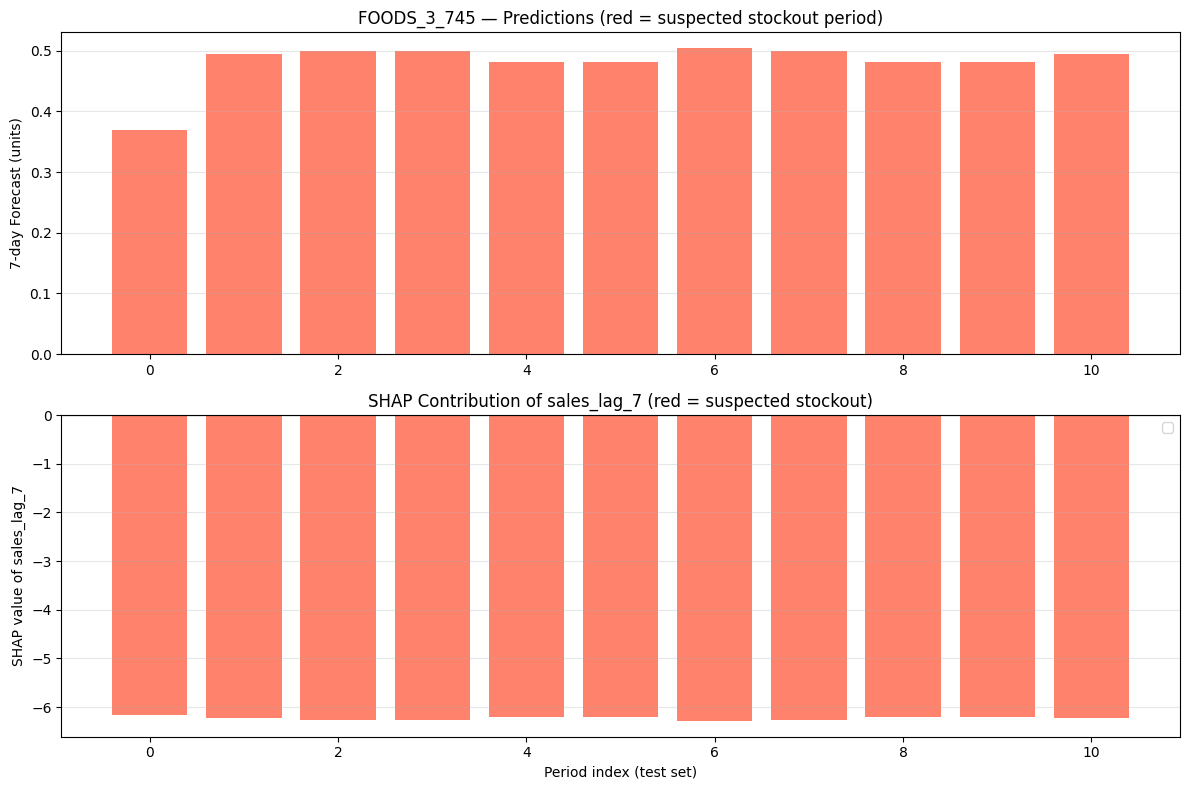

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

colors = ['tomato' if z else 'steelblue' for z in impact_df['is_zero_lag']]

# Top: prediction with stockout periods highlighted
axes[0].bar(range(len(impact_df)), impact_df['prediction'], color=colors, alpha=0.8)
axes[0].set_ylabel('7-day Forecast (units)')
axes[0].set_title(f'{target_sku} — Predictions (red = suspected stockout period)')
axes[0].grid(axis='y', alpha=0.3)

# Bottom: SHAP of sales_lag_7
axes[1].bar(range(len(impact_df)), impact_df['shap_lag7'], color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
if normal_mask.any():
    axes[1].axhline(avg_shap_normal, color='steelblue', linestyle='--', linewidth=1.2, label=f'Normal mean ({avg_shap_normal:.2f})')
axes[1].set_ylabel('SHAP value of sales_lag_7')
axes[1].set_title('SHAP Contribution of sales_lag_7 (red = suspected stockout)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.xlabel('Period index (test set)')
plt.tight_layout()
plt.show()

## 6) Estimate Censored Demand

In [6]:
censored_df = estimate_censored_demand(
    df         = full_df,
    sku_id     = target_sku,
    sku_col    = 'item_id',
    sales_col  = TARGET,
    date_col   = 'date',
    lag_col    = 'sales_lag_7',
)

total_lost = float(censored_df['demand_gap'].sum())
print(f'Total estimated lost demand: {total_lost:.1f} units')
print()
print(censored_df[['date', 'sales_lag_7', TARGET, 'estimated_demand', 'demand_gap', 'is_potential_stockout']]
      .head(20).to_string(index=False))

Total estimated lost demand: 16.3 units

      date  sales_lag_7  aggregated_sales_7  estimated_demand  demand_gap  is_potential_stockout
2015-01-07          0.0                   0          1.000000    1.000000                      1
2015-01-14          0.0                   0          1.000000    1.000000                      1
2015-01-21          0.0                   0          1.000000    1.000000                      1
2015-01-28          0.0                   1          1.000000    0.000000                      1
2015-02-04          1.0                   1          1.000000    0.000000                      0
2015-02-11          1.0                   1          1.000000    0.000000                      0
2015-02-18          1.0                   2          2.000000    0.000000                      0
2015-02-25          2.0                   2          2.000000    0.000000                      0
2015-03-04          2.0                   4          4.000000    0.000000             

## 7) Visualize Censored Demand

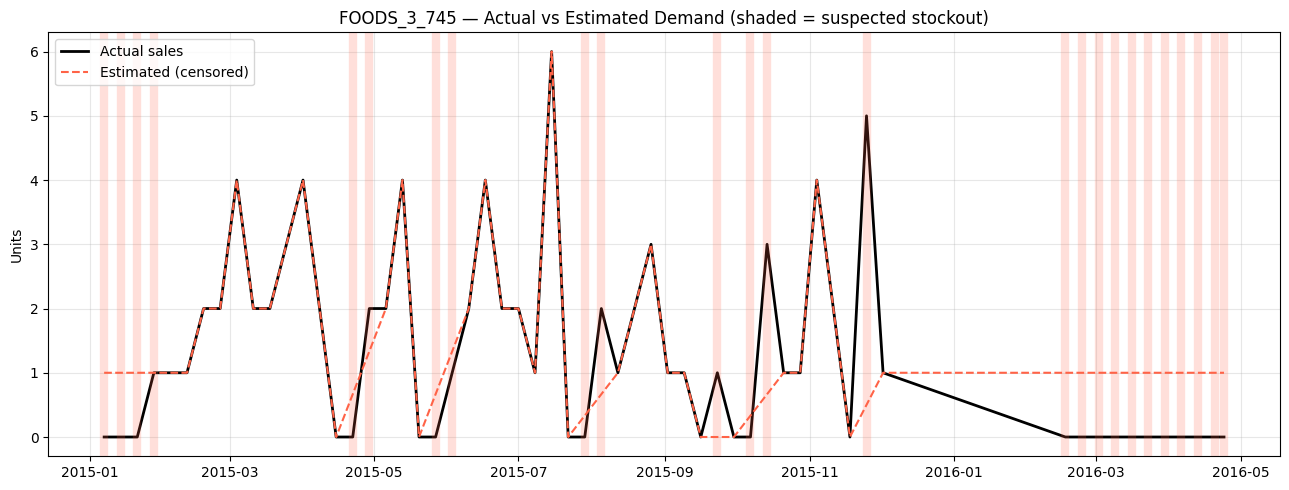

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(censored_df['date'], censored_df[TARGET],           label='Actual sales',         color='black', linewidth=2)
ax.plot(censored_df['date'], censored_df['estimated_demand'], label='Estimated (censored)', color='tomato', linestyle='--', linewidth=1.5)

stockout_dates = censored_df[censored_df['is_potential_stockout'] == 1]['date']
for d in stockout_dates:
    ax.axvline(d, color='tomato', alpha=0.2, linewidth=6)

ax.set_ylabel('Units')
ax.set_title(f'{target_sku} — Actual vs Estimated Demand (shaded = suspected stockout)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8) NLG Stockout Warning

In [8]:
n_so_test = int(impact_df['is_zero_lag'].sum())

text = generate_stockout_text(
    sku_id                = target_sku,
    n_stockout_periods    = n_so_test,
    avg_shap_impact       = float(avg_distortion),
    estimated_lost_demand = total_lost,
    total_periods         = len(impact_df),
)
print(text)

=== Stockout Distortion Analysis: FOODS_3_745 ===
Suspected stockout periods: 11 / 11 (100.0% of history)
Average SHAP distortion during stockout periods: -6.231 units  [HIGH severity]
The model is likely underestimating demand for FOODS_3_745 because the sales lag feature carries zero values from periods where stock may have been unavailable.
Estimated total censored demand: 16.3 units across stockout periods.
This demand was never observed — the model learned from artificially low sales and may continue to under-forecast this SKU.

Recommendation: treat forecasts for this SKU with caution. Consider enriching with actual inventory data to distinguish true zero demand from stockouts.


## 9) Stockout Risk Summary Across All SKUs

In [9]:
summary = (
    flagged_df.groupby('item_id')
    .agg(
        total_periods    = ('is_potential_stockout', 'count'),
        stockout_periods = ('is_potential_stockout', 'sum'),
    )
    .assign(stockout_rate=lambda d: d['stockout_periods'] / d['total_periods'])
    .sort_values('stockout_rate', ascending=False)
    .reset_index()
)

print(f'SKUs with any stockout flag: {(summary["stockout_periods"] > 0).sum()} / {len(summary)}')
print()
print('Top 15 highest stockout-risk SKUs:')
print(summary.head(15).to_string(index=False))

SKUs with any stockout flag: 1437 / 1437

Top 15 highest stockout-risk SKUs:
    item_id  total_periods  stockout_periods  stockout_rate
FOODS_3_293             59                55       0.932203
FOODS_1_079             59                50       0.847458
FOODS_3_350             59                50       0.847458
FOODS_3_220             59                49       0.830508
FOODS_3_595             59                49       0.830508
FOODS_2_261             59                49       0.830508
FOODS_2_256             59                49       0.830508
FOODS_2_117             59                49       0.830508
FOODS_3_296             59                49       0.830508
FOODS_3_422             59                48       0.813559
FOODS_3_522             59                48       0.813559
FOODS_2_209             59                48       0.813559
FOODS_3_093             59                47       0.796610
FOODS_1_072             59                47       0.796610
FOODS_3_347            